
# Week 4: Surface Water Detection with Semantic Segmentation

## Overview
This notebook introduces a practical GeoAI workflow for **surface water detection from satellite imagery** using semantic segmentation. It is designed as a teaching notebook for GitHub-based learning and aligns with the flood and disaster management focus of this course.

The workflow uses a segmentation-based approach to identify water pixels from geospatial imagery and demonstrate how this supports flood extent mapping and environmental monitoring.

## Learning Objectives
- Understand why semantic segmentation is useful for flood and surface water mapping
- Load and organize geospatial imagery and corresponding mask data
- Prepare tiled image patches for training
- Train or review a segmentation workflow
- Run inference on validation imagery
- Compare predicted surface water masks with reference masks
- Understand how vectorized outputs can support geospatial analysis

## Expected Outcome
By the end of this notebook, you should understand the structure of a surface water segmentation workflow and be able to run or explain the main steps involved in building a pixel-level water detection pipeline.



## Notebook Structure

1. Environment setup  
2. Why segmentation matters for flood and water mapping  
3. Install and import required tools  
4. Download and inspect the dataset  
5. Define image and mask paths  
6. Export tiles for model training  
7. Train a segmentation model  
8. Review performance curves  
9. Run inference on validation imagery  
10. Vectorize predictions and visualize results  
11. Mini exercise  
12. Weekly assignment  

> This notebook follows a **practical workflow style** and is intended to help students see how a geospatial deep learning pipeline is organized from start to finish.



## Why Segmentation Matters for Surface Water Detection

Flood and surface water mapping is often a **pixel-level problem**. Water can spread across irregular shapes, roads, fields, urban blocks, and low-lying terrain. A scene-level label is usually not enough.

Semantic segmentation is well suited because it answers:

> **Which exact pixels in the image belong to surface water?**

This makes segmentation valuable for:
- flood extent mapping
- urban inundation monitoring
- post-event water footprint analysis
- environmental waterbody detection
- decision support for disaster operations


In [1]:

# Week 4 setup: basic imports

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())


Python version: 3.12.12
Working directory: /content


In [2]:

# Create output folder for this week

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "week04"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)


Output directory ready: /content/outputs/week04



## Initialization Step

This workflow uses the `geoai-py` package to simplify common geospatial deep learning tasks such as:
- downloading a sample dataset
- creating tiles from large geospatial scenes
- training a segmentation model
- plotting training curves
- running batch inference
- converting raster predictions to vector outputs

If the package is not already available in your environment, install it using the next cell.


In [3]:

# Install geoai-py if needed
# Uncomment and run in a fresh environment

# %pip install geoai-py


In [4]:

# Import GeoAI package after installation
# Run this cell only after geoai-py is available

# import geoai
# print("geoai-py imported successfully")



## Load a Sample Dataset

The original workflow uses a small Sentinel-2 sample dataset packaged for teaching and experimentation.  
The following cell shows the download pattern used in the reference workflow.

This dataset contains:
- training scenes
- training masks
- validation scenes
- validation masks

> Note: downloading requires internet access in the runtime environment.


In [5]:

# Example dataset download
# Uncomment when running in an environment with internet access

# url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/dset-s2.zip"
# data_dir = geoai.download_file(url)
# print("Dataset downloaded to:", data_dir)



## Define Data Paths

After download, the workflow typically organizes imagery and masks into separate folders.  
The paths below follow the same structure as the reference notebook.


In [6]:

# Example path setup after dataset download
# Replace data_dir with your actual extracted dataset path if needed

# images_dir = f"{data_dir}/dset-s2/tra_scene"
# masks_dir = f"{data_dir}/dset-s2/tra_truth"
# tiles_dir = f"{data_dir}/dset-s2/tiles"

# print("Training image directory:", images_dir)
# print("Training mask directory:", masks_dir)
# print("Tile output directory:", tiles_dir)



## Conceptual View of the Workflow

The segmentation pipeline can be summarized as:

1. Load raw geospatial scenes  
2. Load reference mask data  
3. Split large scenes into smaller aligned tiles  
4. Train a segmentation model on image-mask pairs  
5. Evaluate learning behavior  
6. Run inference on unseen scenes  
7. Compare predictions to ground truth  
8. Convert raster results to vectors when needed  

This is a common pattern in geospatial deep learning.


In [7]:

# Visual conceptual diagram using plain Python structures

workflow_steps = pd.DataFrame({
    "Step": [
        "Load scenes",
        "Load masks",
        "Tile the data",
        "Train segmentation model",
        "Evaluate training history",
        "Run validation inference",
        "Compare with ground truth",
        "Vectorize outputs"
    ],
    "Purpose": [
        "Read raw geospatial imagery",
        "Read reference labels",
        "Create manageable training patches",
        "Learn water vs non-water patterns",
        "Check model behavior over time",
        "Predict on unseen imagery",
        "Assess prediction quality",
        "Support map-based analysis"
    ]
})

workflow_steps


,Step,Purpose
0,Load scenes,Read raw geospatial imagery
1,Load masks,Read reference labels
2,Tile the data,Create manageable training patches
3,Train segmentation model,Learn water vs non-water patterns
4,Evaluate training history,Check model behavior over time
5,Run validation inference,Predict on unseen imagery
6,Compare with ground truth,Assess prediction quality
7,Vectorize outputs,Support map-based analysis



## Export Training Tiles

Large geospatial scenes are usually too large to use directly for deep learning training.  
A common solution is to split them into smaller **tiles** while preserving image-mask alignment.

The cell below shows the typical tiling structure used in the reference workflow.


In [8]:

# Example tiling workflow
# Uncomment when running with geoai-py and a prepared dataset

# result = geoai.export_geotiff_tiles_batch(
#     images_folder=images_dir,
#     masks_folder=masks_dir,
#     output_dir=tiles_dir,
#     tile_size=256,
#     stride=256,
#     image_band_indices=[3, 2, 1]
# )
# print(result)



### Why Tiling Helps
- reduces memory pressure
- increases the number of training samples
- standardizes input shape
- makes batch training easier
- supports patch-based inference workflows



## Model Training

The reference workflow uses a **U-Net segmentation model with a ResNet34 encoder**, which is a common and effective architecture for segmentation tasks in remote sensing.

Students do not need to fully master the architecture details in this week. The main goal is to understand:
- model input: image tiles
- model target: water masks
- model output: per-pixel water probability or class prediction


In [9]:

# Example model training call
# Uncomment when running with geoai-py

# geoai.train_segmentation_model(
#     images_dir=f"{tiles_dir}/images",
#     masks_dir=f"{tiles_dir}/masks",
#     model_name="unet",
#     encoder_name="resnet34",
#     batch_size=4,
#     num_epochs=10,
#     learning_rate=1e-3,
#     output_dir=f"{tiles_dir}/unet_models"
# )



## Performance Review

After training, it is important to review how the model behaved across epochs.  
Common things to check:
- training loss decreases
- validation loss decreases or stabilizes
- segmentation quality improves
- signs of overfitting are limited

The reference notebook uses a built-in plotting function to inspect training history.


In [10]:

# Example performance plotting
# Uncomment when training history is available

# geoai.plot_performance_metrics(
#     history_path=f"{tiles_dir}/unet_models/training_history.pth"
# )



## Run Inference on Validation Data

Once a model is trained, it can be applied to validation or test imagery to generate predicted surface water masks.


In [11]:

# Example validation path setup
# Uncomment and adjust after dataset download

# val_images_dir = f"{data_dir}/dset-s2/val_scene"
# val_masks_dir = f"{data_dir}/dset-s2/val_truth"
# pred_dir = f"{tiles_dir}/predictions"

# print("Validation images:", val_images_dir)
# print("Validation masks:", val_masks_dir)
# print("Prediction output directory:", pred_dir)


In [12]:

# Example batch inference
# Uncomment when model weights and validation data are available

# geoai.semantic_segmentation_batch(
#     input_dir=val_images_dir,
#     output_dir=pred_dir,
#     model_path=f"{tiles_dir}/unet_models/best_model.pth",
#     tile_size=256,
#     stride=256
# )



## Vectorize Predicted Masks

Raster predictions are useful for model output, but vectorized polygons are often easier to integrate into GIS workflows, dashboards, and map overlays.

This step is especially useful when the goal is to:
- measure water-covered area
- overlay predictions on base maps
- integrate outputs into urban digital twin systems
- support spatial decision-making


In [13]:

# Example vectorization workflow
# Uncomment after predictions have been generated

# geoai.raster_to_vector(
#     input_raster=f"{pred_dir}/sample_prediction.tif",
#     output_vector=f"{pred_dir}/sample_prediction.geojson"
# )



## Synthetic Illustration of Image, Ground Truth, and Predicted Mask

The next cell creates a simple synthetic demonstration so students can understand the comparison logic even before running the full geospatial workflow.


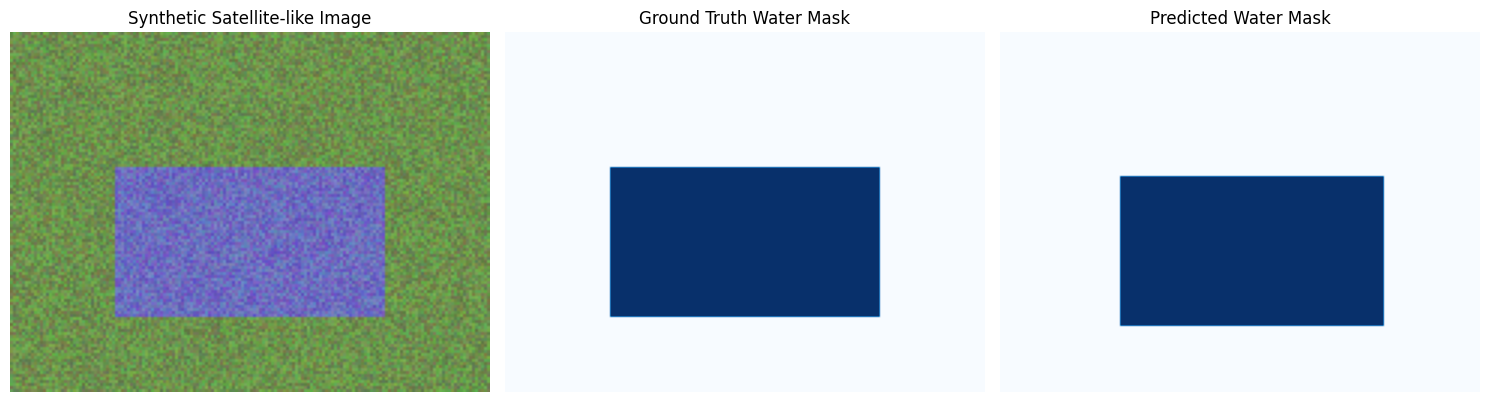

In [14]:

# Synthetic comparison of image, ground-truth mask, and predicted mask

np.random.seed(42)

image = np.zeros((120, 160, 3))
image[..., 1] = 0.45 + 0.25 * np.random.rand(120, 160)
image[..., 0] = 0.35 + 0.15 * np.random.rand(120, 160)
image[..., 2] = 0.25 + 0.10 * np.random.rand(120, 160)

# Synthetic water body
image[45:95, 35:125, 2] += 0.45
image[45:95, 35:125, 1] -= 0.15
image = np.clip(image, 0, 1)

ground_truth = np.zeros((120, 160), dtype=int)
ground_truth[45:95, 35:125] = 1

prediction = np.zeros((120, 160), dtype=int)
prediction[48:98, 40:128] = 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(image)
axes[0].set_title("Synthetic Satellite-like Image")
axes[0].axis("off")

axes[1].imshow(ground_truth, cmap="Blues")
axes[1].set_title("Ground Truth Water Mask")
axes[1].axis("off")

axes[2].imshow(prediction, cmap="Blues")
axes[2].set_title("Predicted Water Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [15]:

# Compute simple segmentation metrics for the synthetic example

def mask_iou(y_true_mask, y_pred_mask):
    intersection = np.logical_and(y_true_mask == 1, y_pred_mask == 1).sum()
    union = np.logical_or(y_true_mask == 1, y_pred_mask == 1).sum()
    return intersection / union if union > 0 else 0.0

def dice_score(y_true_mask, y_pred_mask):
    intersection = np.logical_and(y_true_mask == 1, y_pred_mask == 1).sum()
    total = (y_true_mask == 1).sum() + (y_pred_mask == 1).sum()
    return 2 * intersection / total if total > 0 else 0.0

synthetic_iou = mask_iou(ground_truth, prediction)
synthetic_dice = dice_score(ground_truth, prediction)

metric_table = pd.DataFrame({
    "Metric": ["IoU", "Dice Score"],
    "Value": [round(synthetic_iou, 3), round(synthetic_dice, 3)]
})

metric_table


,Metric,Value
0,IoU,0.814
1,Dice Score,0.898



### Interpretation
- **IoU** measures the overlap between predicted water pixels and true water pixels.
- **Dice Score** also measures overlap but emphasizes similarity between the two masks.
- In real flood workflows, these metrics help compare segmentation performance across models or datasets.



## Suggested Discussion Questions

1. Why is segmentation a better fit than simple classification for surface water mapping?
2. Why do large geospatial scenes need to be tiled before training?
3. Why might vectorized outputs be useful after prediction?
4. How could this workflow support flood monitoring in a real city?


In [16]:

# Write your Week 4 discussion responses here

# 1.
# 2.
# 3.
# 4.



## Weekly Assignment

Create a short written response that includes the following:

1. Describe the full surface water detection workflow in your own words
2. Explain the role of image tiles, masks, and segmentation models
3. State one benefit and one limitation of using satellite imagery for flood or water detection
4. Explain how this workflow could support disaster preparedness or rapid assessment

You may respond in a markdown cell or the code cell below.


In [17]:

# Week 4 assignment response area

workflow_summary = ""
benefit = ""
limitation = ""
disaster_phase_support = ""

print("Workflow Summary:", workflow_summary)
print("Benefit:", benefit)
print("Limitation:", limitation)
print("Disaster Phase Support:", disaster_phase_support)


Workflow Summary: 
Benefit: 
Limitation: 
Disaster Phase Support: 



## Key Takeaway

The main lesson from Week 4 is:

> **Surface water detection is a strong example of how GeoAI turns geospatial imagery into actionable spatial intelligence.**

Semantic segmentation is especially valuable because it provides **pixel-level mapping**, which is far more informative than a single scene label when the goal is to understand flood extent or water presence.



## Suggested Extensions

Later versions of this notebook can be expanded with:
- direct execution of the full `geoai-py` workflow
- real Sentinel-2 visualization
- comparison of multiple segmentation models
- confusion maps for false positives and false negatives
- integration with vector overlays and GIS viewers

This keeps the current notebook course-friendly while allowing a path toward more advanced research or deployment work.
